In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
sns.set_style("whitegrid")

In [9]:
df = pd.read_csv('../data/heart.csv')
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1


# Основная информация о данных 

In [10]:
print(f"Размер данных: {df.shape[0]} строк, {df.shape[1]} столбцов")
print(f"\nТипы данных:")
print(df.dtypes.value_counts())

Размер данных: 1025 строк, 14 столбцов

Типы данных:
int64      13
float64     1
Name: count, dtype: int64


# Первичный анализ(EDA)

In [12]:
print("\nПервые 5 строк ")
print(df.head())

print("\nПоследние 5 строк ")
print(df.tail())



Первые 5 строк 
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1        0      155      1      3.1      0   
2   70    1   0       145   174    0        1      125      1      2.6      0   
3   61    1   0       148   203    0        1      161      0      0.0      2   
4   62    0   0       138   294    1        1      106      0      1.9      1   

   ca  thal  target  
0   2     3       0  
1   0     3       0  
2   0     3       0  
3   1     3       0  
4   3     2       0  

Последние 5 строк 
      age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  \
1020   59    1   1       140   221    0        1      164      1      0.0   
1021   60    1   0       125   258    0        0      141      1      2.8   
1022   47    1   0       110   275    0        0      118      1      1.0   
1023   50    0   0       110   254  

In [14]:
print("\n Статистика числовых признаков ")
numeric_cols = df.select_dtypes(include=[np.number]).columns
if len(numeric_cols) > 0:
    print(df[numeric_cols].describe())
else:
    print("Нет числовых признаков!")


 Статистика числовых признаков 
               age          sex           cp     trestbps        chol  \
count  1025.000000  1025.000000  1025.000000  1025.000000  1025.00000   
mean     54.434146     0.695610     0.942439   131.611707   246.00000   
std       9.072290     0.460373     1.029641    17.516718    51.59251   
min      29.000000     0.000000     0.000000    94.000000   126.00000   
25%      48.000000     0.000000     0.000000   120.000000   211.00000   
50%      56.000000     1.000000     1.000000   130.000000   240.00000   
75%      61.000000     1.000000     2.000000   140.000000   275.00000   
max      77.000000     1.000000     3.000000   200.000000   564.00000   

               fbs      restecg      thalach        exang      oldpeak  \
count  1025.000000  1025.000000  1025.000000  1025.000000  1025.000000   
mean      0.149268     0.529756   149.114146     0.336585     1.071512   
std       0.356527     0.527878    23.005724     0.472772     1.175053   
min       0.0

In [21]:
print("\nАнализ пропусков")
df.isna().sum()
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_table = pd.DataFrame({
    'Кол-во пропусков': missing,
    '% пропусков': missing_pct
}).sort_values('% пропусков', ascending=False)
print(missing_table[missing_table['Кол-во пропусков'] > 0])


Анализ пропусков
Empty DataFrame
Columns: [Кол-во пропусков, % пропусков]
Index: []


Заметим, что нет пропусков, значит хороший датасет

# Полная информация о данных 

In [22]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


# Визуализация распределений 

In [ ]:
import os
# Создадим директорию для графиков
if not os.path.exists('eda_plots'):
    os.makedirs('eda_plots')

Создадим директорию для графиков


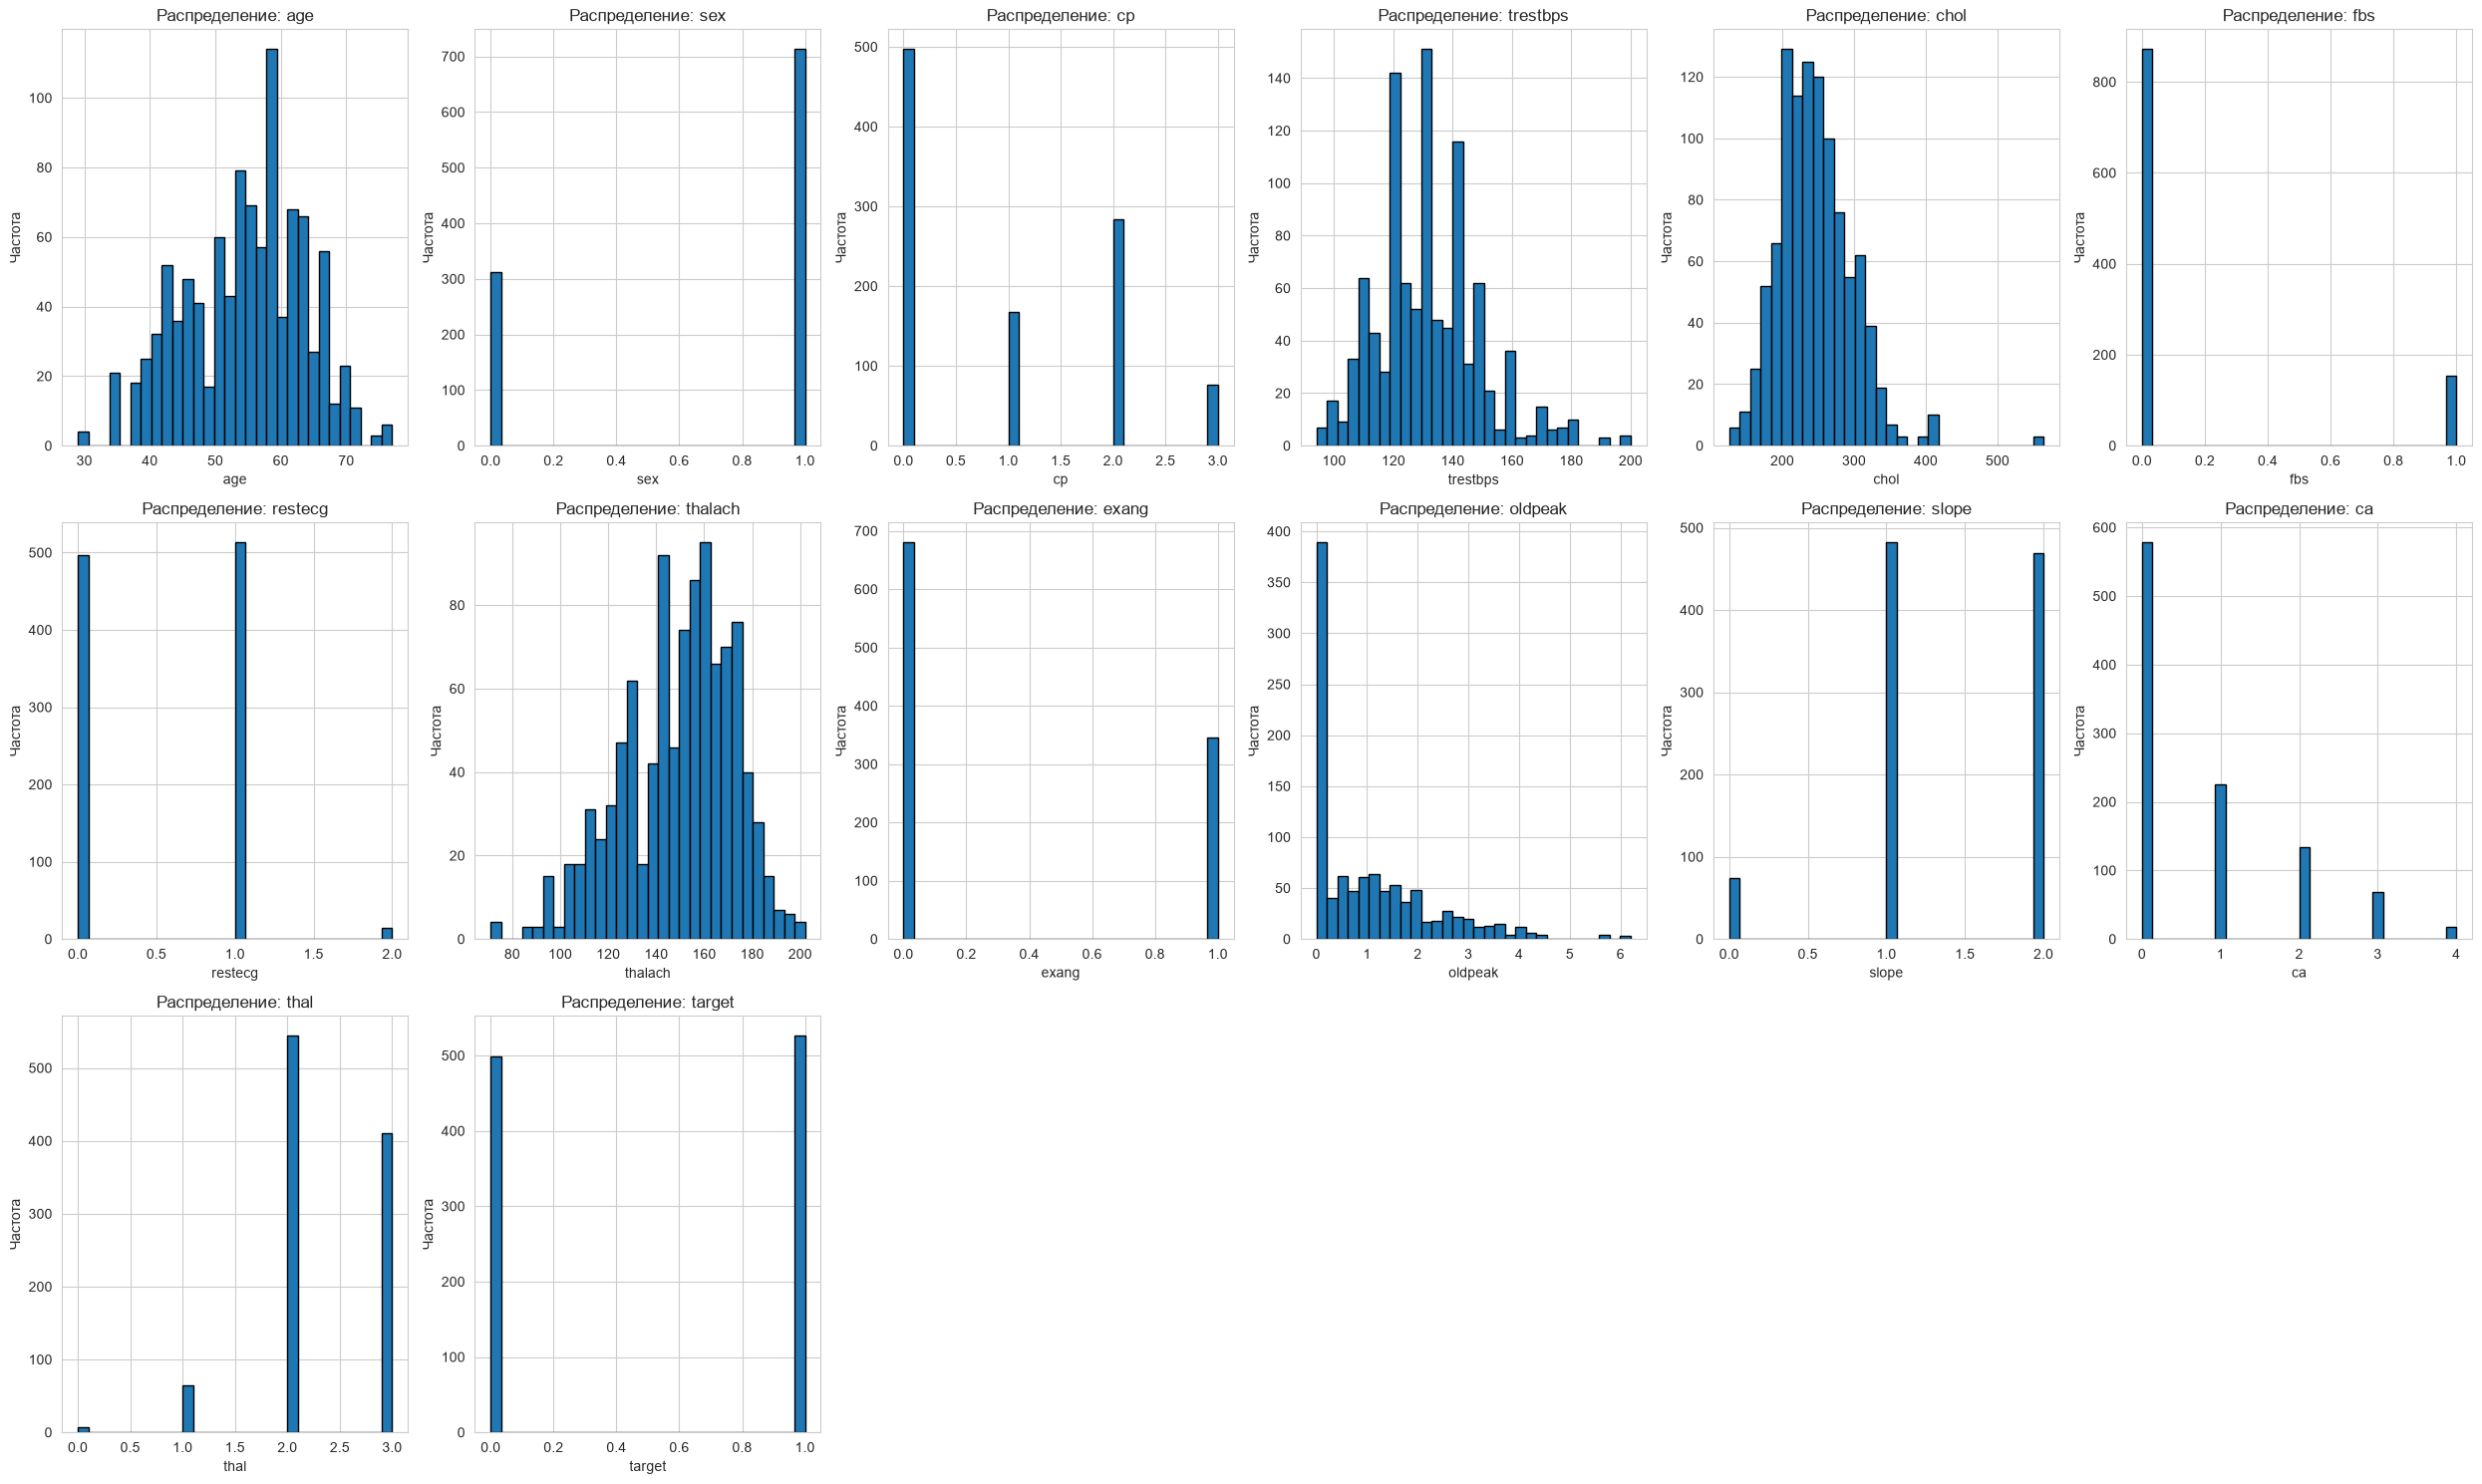

In [25]:
# Гистрограммы для числовых признаков
if len(numeric_cols) > 0:
    n_cols = min(6, len(numeric_cols))
    n_rows = (len(numeric_cols) + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(25, 5*n_rows))
    axes = axes.flatten() if n_rows > 1 else [axes] if n_cols > 1 else [axes]
    
    for i, col in enumerate(numeric_cols):
        axes[i].hist(df[col].dropna(), bins=30, edgecolor='black')
        axes[i].set_title(f'Распределение: {col}')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Частота')
    
    # Убираем пустые подграфики
    for j in range(i+1, len(axes)):
        axes[j].set_visible(False)
    
    plt.tight_layout()
    plt.savefig('eda_plots/1_distributions.png', dpi=150)
    plt.show()

Boxplots для выявления выбросов 

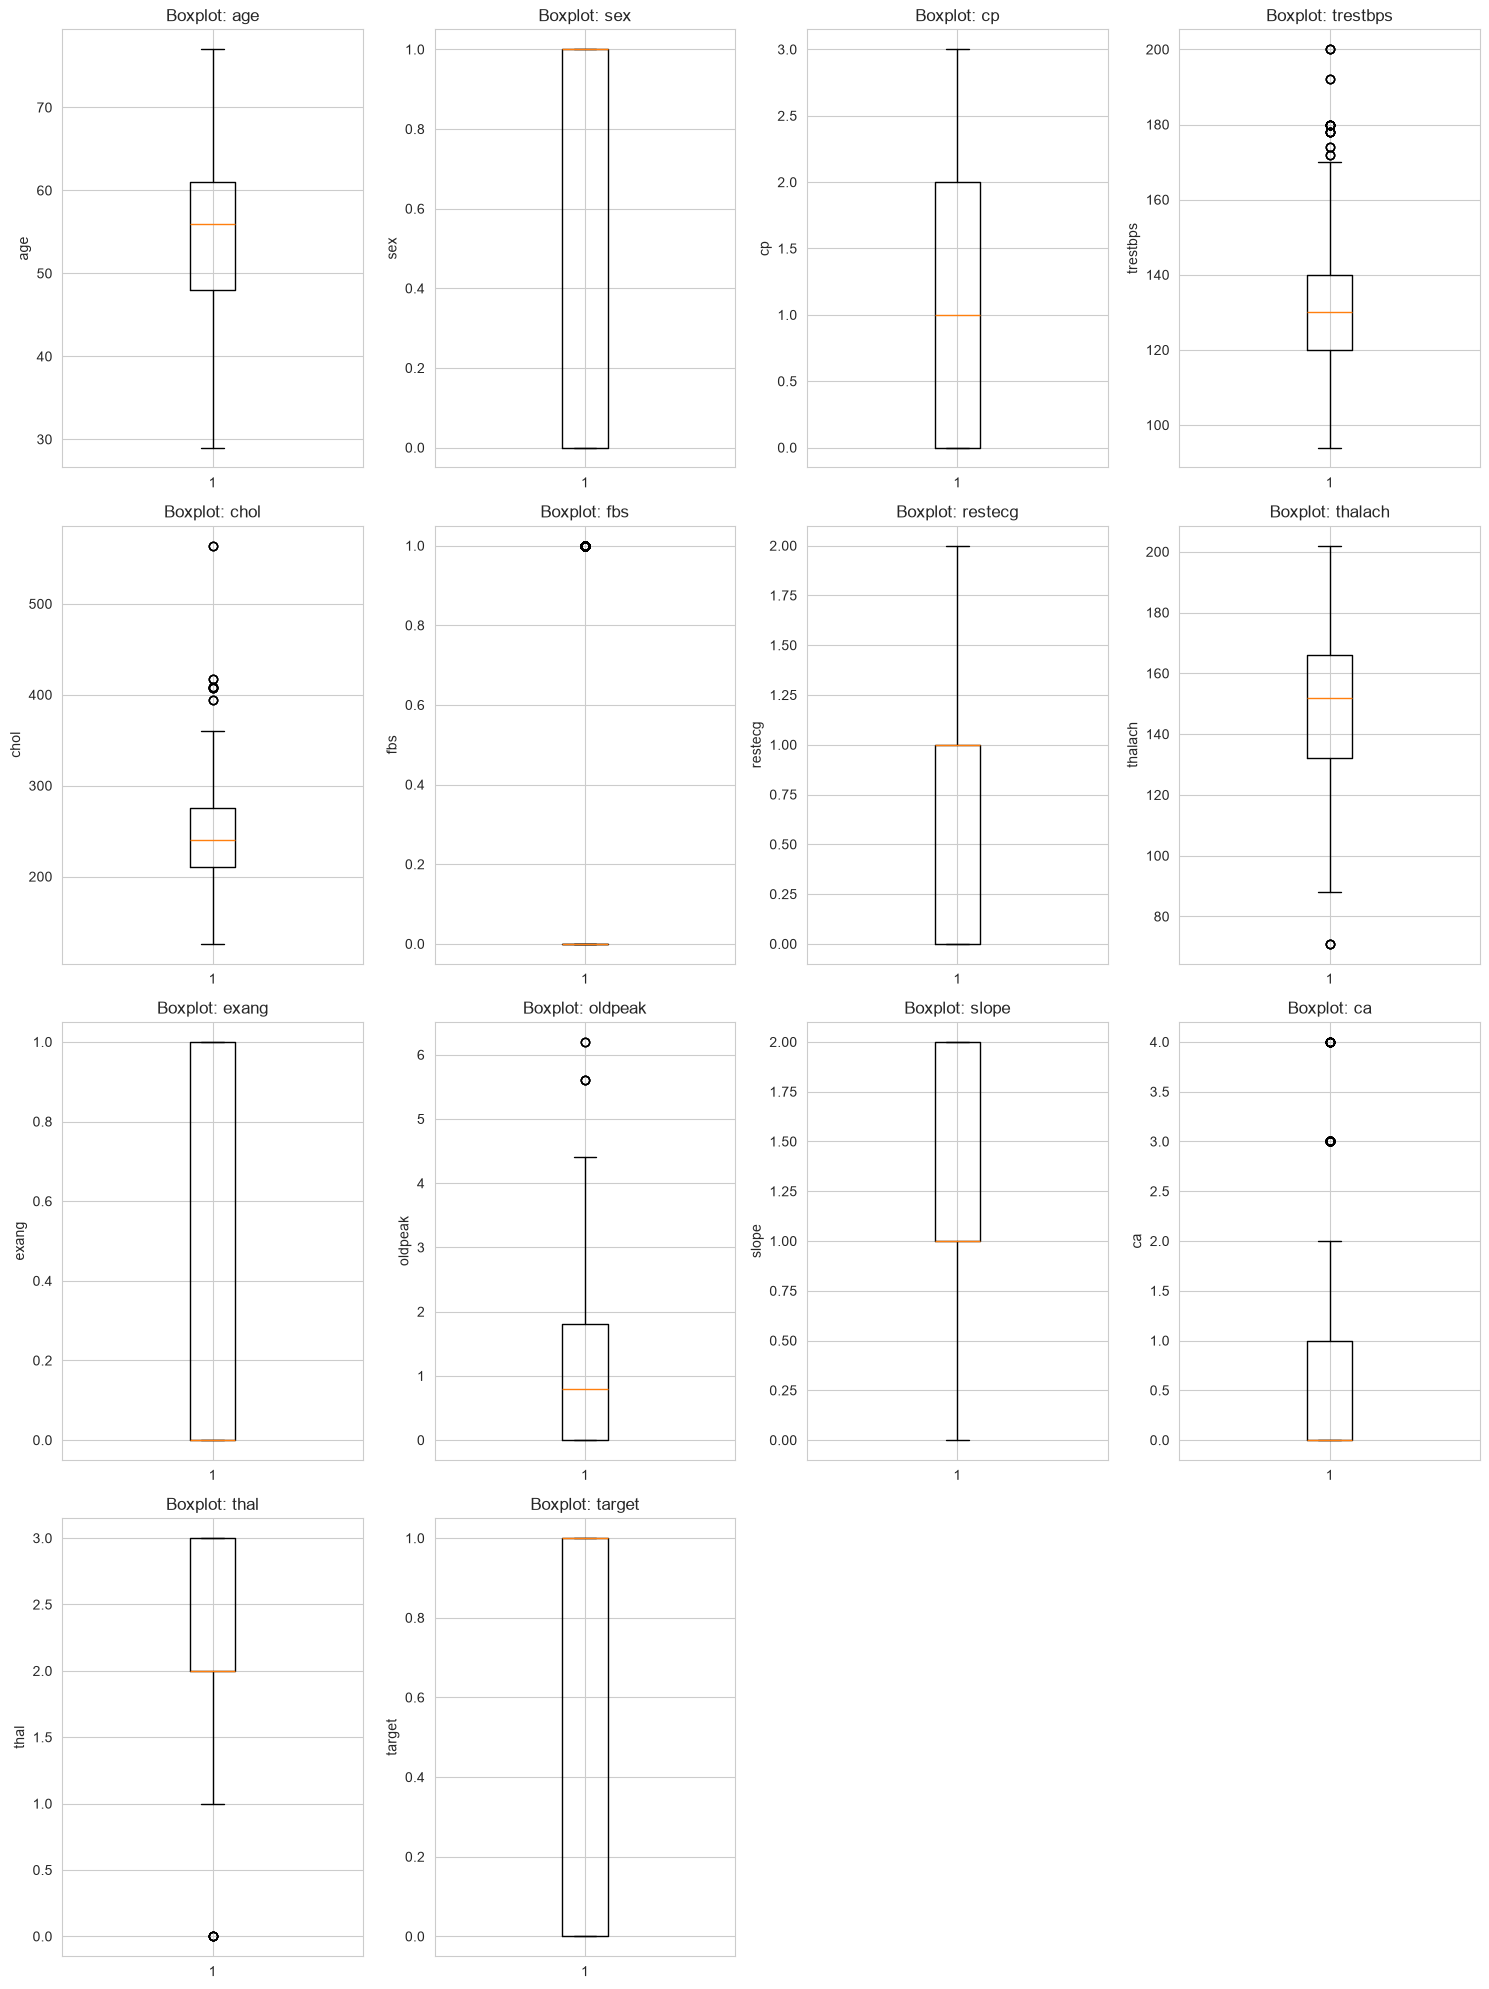

In [26]:
if len(numeric_cols) > 0:
    n_cols = min(4, len(numeric_cols))
    n_rows = (len(numeric_cols) + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows))
    axes = axes.flatten() if n_rows > 1 else [axes] if n_cols > 1 else [axes]
    
    for i, col in enumerate(numeric_cols):
        axes[i].boxplot(df[col].dropna())
        axes[i].set_title(f'Boxplot: {col}')
        axes[i].set_ylabel(col)
    
    for j in range(i+1, len(axes)):
        axes[j].set_visible(False)
    
    plt.tight_layout()
    plt.savefig('eda_plots/2_boxplots.png', dpi=150)
    plt.show()

# Анализ выбросов

In [28]:
from scipy import stats

if len(numeric_cols) > 0:
    outliers_report = []
    for col in numeric_cols:
        col_data = df[col].dropna()
        z_scores = np.abs(stats.zscore(col_data))
        outliers = np.where(z_scores > 3)[0]
        outliers_report.append({
            'Признак': col,
            'Кол-во выбросов': len(outliers),
            '% выбросов': (len(outliers) / len(col_data)) * 100
        })
    
    outliers_df = pd.DataFrame(outliers_report)
    print(outliers_df)

     Признак  Кол-во выбросов  % выбросов
0        age                0    0.000000
1        sex                0    0.000000
2         cp                0    0.000000
3   trestbps                7    0.682927
4       chol               13    1.268293
5        fbs                0    0.000000
6    restecg                0    0.000000
7    thalach                4    0.390244
8      exang                0    0.000000
9    oldpeak                7    0.682927
10     slope                0    0.000000
11        ca               18    1.756098
12      thal                7    0.682927
13    target                0    0.000000


# Корреляционный анализ

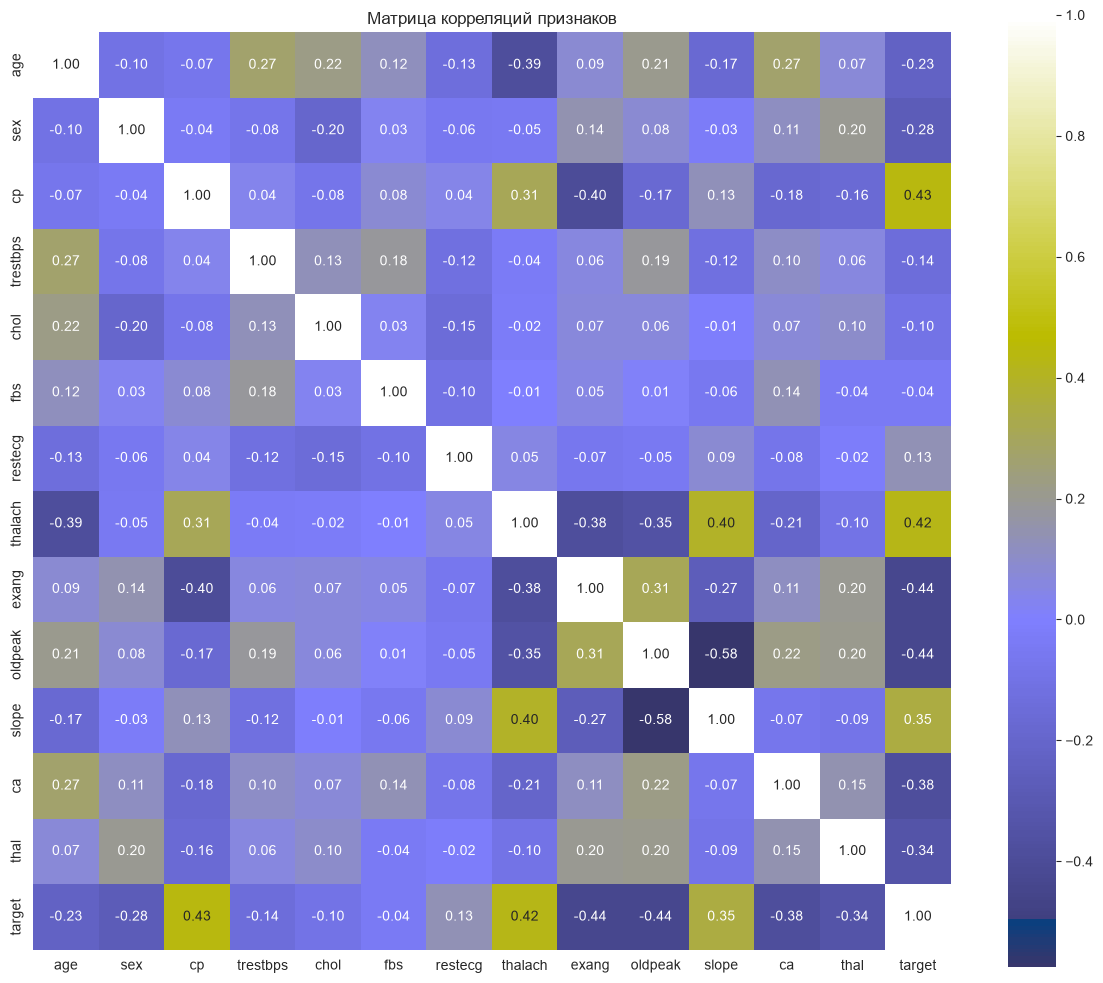


Сильных корреляций не обнаружено


In [32]:
if len(numeric_cols) > 1:
    # Матрица корреляций
    corr_matrix = df[numeric_cols].corr()
    
    # Тепловая карта корреляций
    plt.figure(figsize=(12, 10))
    sns.heatmap(corr_matrix, annot=True, cmap='gist_stern', center=0, 
                fmt='.2f', square=True)
    plt.title('Матрица корреляций признаков')
    plt.tight_layout()
    plt.savefig('eda_plots/3_correlation_matrix.png', dpi=150)
    plt.show()
    
    # Сильные корреляции (>0.7 или < -0.7)
    strong_corrs = []
    for i in range(len(corr_matrix.columns)):
        for j in range(i+1, len(corr_matrix.columns)):
            if abs(corr_matrix.iloc[i, j]) > 0.7:
                strong_corrs.append({
                    'Признак 1': corr_matrix.columns[i],
                    'Признак 2': corr_matrix.columns[j],
                    'Корреляция': corr_matrix.iloc[i, j]
                })
    
    if strong_corrs:
        print("\nСильные корреляции (|r| > 0.7):")
        print(pd.DataFrame(strong_corrs))
        print("\nРекомендация: можно оставить один из сильно коррелирующих признаков")
    else:
        print("\nСильных корреляций не обнаружено")

# Анализ целевой переменной


Распределение целевой переменной 'target':
   Значение  Количество          %
0         1         526  51.317073
1         0         499  48.682927

Минимальный класс составляет 48.68% от выборки
 Дисбаланс не критичный


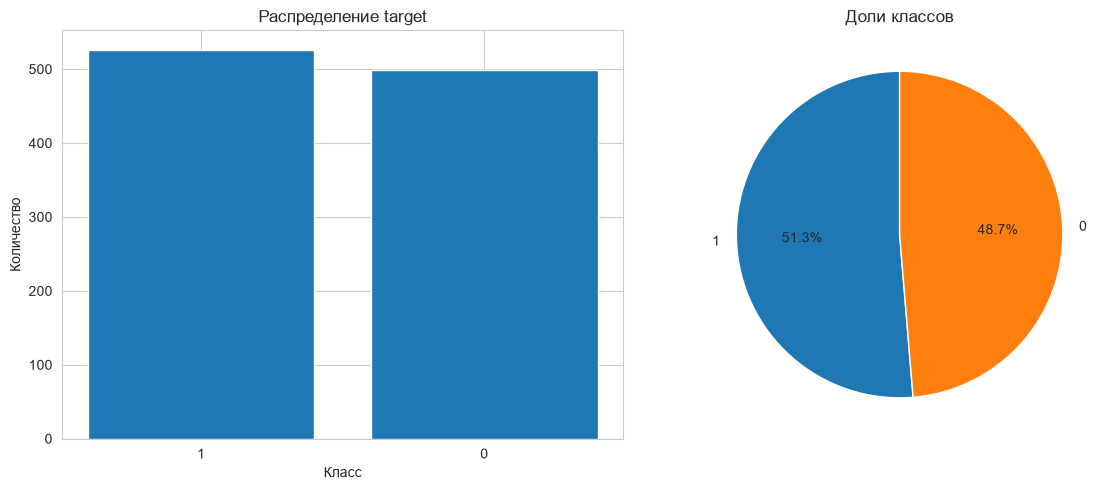

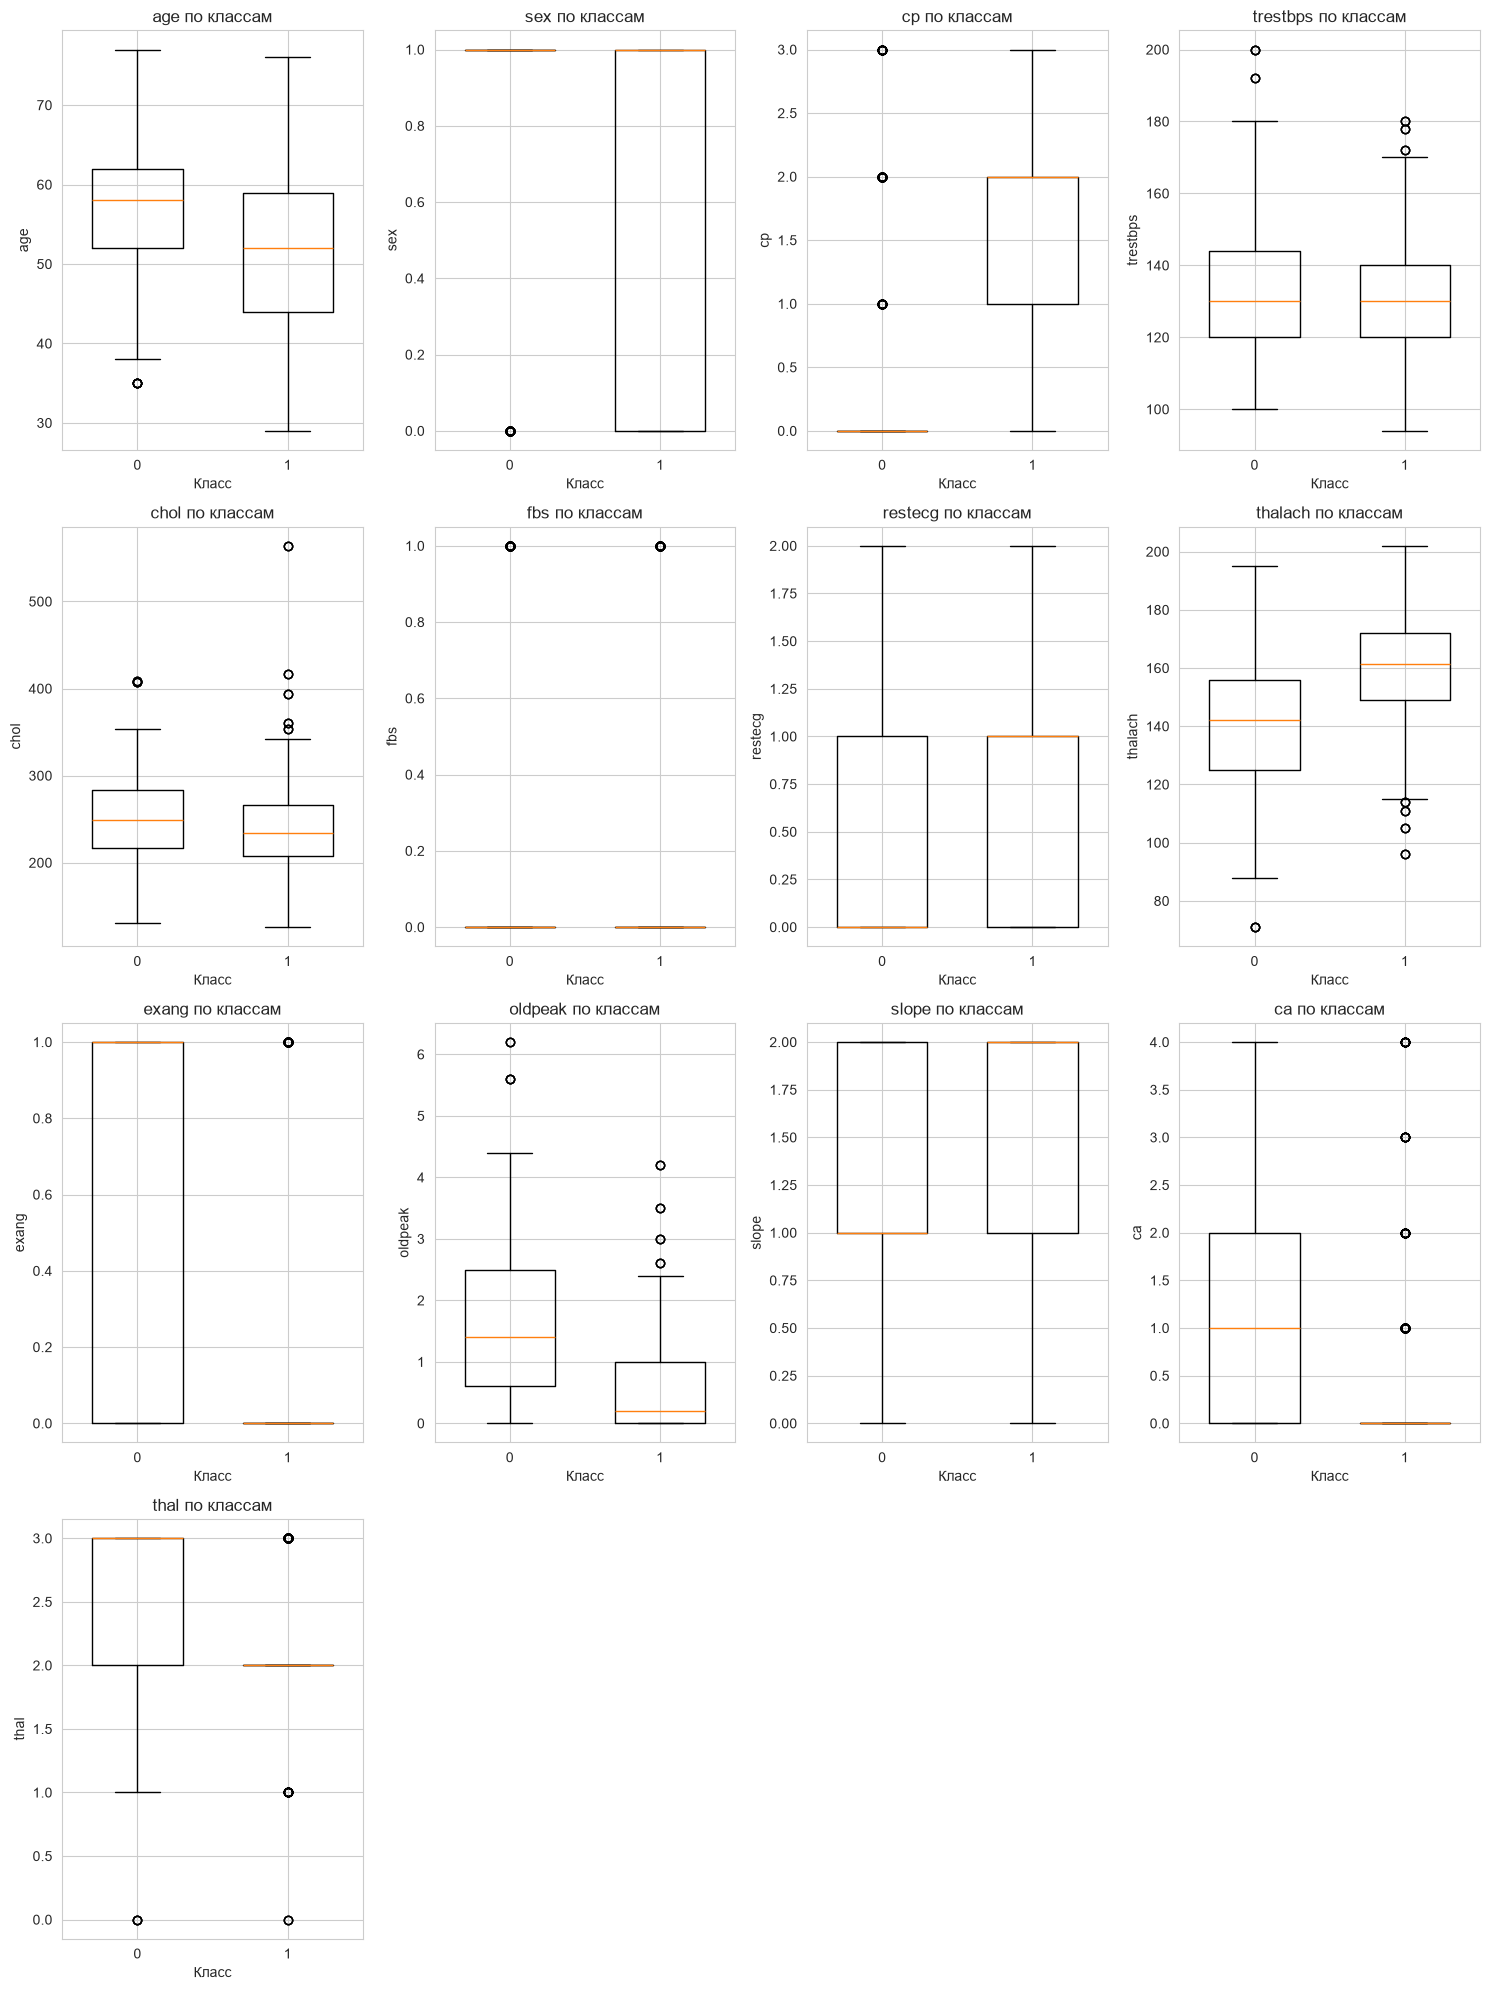

In [33]:
target_col = 'target'
if target_col in df.columns:
    # Распределение целевой переменной
    print(f"\nРаспределение целевой переменной '{target_col}':")
    target_dist = df[target_col].value_counts()
    target_pct = df[target_col].value_counts(normalize=True) * 100
    target_table = pd.DataFrame({
        'Значение': target_dist.index,
        'Количество': target_dist.values,
        '%': target_pct.values
    })
    print(target_table)
    
    # Анализ дисбаланса классов
    min_class_pct = target_pct.min()
    print(f"\nМинимальный класс составляет {min_class_pct:.2f}% от выборки")
    
    if min_class_pct < 10:
        print("Обнаружен сильный дисбаланс классов!")
        print("Рекомендуемые методы борьбы:")
        print(" 1. Использовать class_weight='balanced' в моделях")
        print(" 2. Применить SMOTE для увеличения миноритарного класса")
        print(" 3. Использовать метрики: F1-score, ROC-AUC (не accuracy)")
    else:
        print(" Дисбаланс не критичный")
    
    # Визуализация целевой переменной
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # Столбчатая диаграмма
    axes[0].bar(target_dist.index.astype(str), target_dist.values)
    axes[0].set_title(f'Распределение {target_col}')
    axes[0].set_xlabel('Класс')
    axes[0].set_ylabel('Количество')
    
    # Круговая диаграмма
    axes[1].pie(target_dist.values, labels=target_dist.index.astype(str), 
                autopct='%1.1f%%', startangle=90)
    axes[1].set_title(f'Доли классов')
    
    plt.tight_layout()
    plt.savefig('eda_plots/4_target_distribution.png', dpi=150)
    plt.show()
    
    # Анализ признаков относительно целевой переменной
    if len(numeric_cols) > 0:
        # Boxplots по классам для каждого числового признака
        n_cols = min(4, len(numeric_cols))
        n_rows = (len(numeric_cols) + n_cols - 1) // n_cols
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows))
        axes = axes.flatten() if n_rows > 1 else [axes] if n_cols > 1 else [axes]
        
        for i, col in enumerate([c for c in numeric_cols if c != target_col][:n_cols*n_rows]):
            for class_val in df[target_col].unique():
                class_data = df[df[target_col] == class_val][col].dropna()
                axes[i].boxplot(class_data, positions=[class_val], widths=0.6)
            axes[i].set_title(f'{col} по классам')
            axes[i].set_xlabel('Класс')
            axes[i].set_ylabel(col)
        
        for j in range(i+1, len(axes)):
            axes[j].set_visible(False)
        
        plt.tight_layout()
        plt.savefig('eda_plots/5_features_by_class.png', dpi=150)
        plt.show()

# Предобработка данных

In [34]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

# Создаем копию данных для предобработки
df_processed = df.copy()

In [39]:
# Заполняем пропуски 
for col in df_processed.columns:
    if df_processed[col].isnull().sum() > 0:
        if df_processed[col].dtype in ['int64', 'float64']:
            # Числовые признаки: заполняем медианой
            median_val = df_processed[col].median()
            df_processed[col].fillna(median_val, inplace=True)
            print(f"{col}: заполнено {df[col].isnull().sum()} пропусков медианой ({median_val:.2f})")
        else:
            # Категориальные признаки: заполняем модой
            mode_val = df_processed[col].mode()[0]
            df_processed[col].fillna(mode_val, inplace=True)
            print(f"{col}: заполнено {df[col].isnull().sum()} пропусков модой ('{mode_val}')")

In [43]:
# Обработка выбросов 
outliers_handled = 0
for col in numeric_cols:
    if col != target_col:
        mean = df_processed[col].mean()
        std = df_processed[col].std()
        upper_bound = mean + 3*std
        lower_bound = mean - 3*std
        
        # Определяем тип колонки
        if df_processed[col].dtype == 'int64':
            # Для целочисленных колонок округляем границы и приводим к int
            upper_bound = int(np.ceil(upper_bound))  # округляем вверх
            lower_bound = int(np.floor(lower_bound))  # округляем вниз
        else:
            # Для float колонок оставляем как есть
            pass
        
        outliers = df_processed[(df_processed[col] > upper_bound) | (df_processed[col] < lower_bound)]
        if len(outliers) > 0:
            # Для целочисленных колонок приводим к int
            if df_processed[col].dtype == 'int64':
                df_processed.loc[df_processed[col] > upper_bound, col] = int(upper_bound)
                df_processed.loc[df_processed[col] < lower_bound, col] = int(lower_bound)
            else:
                df_processed.loc[df_processed[col] > upper_bound, col] = upper_bound
                df_processed.loc[df_processed[col] < lower_bound, col] = lower_bound
            outliers_handled += len(outliers)
            print(f"{col}: обработано {len(outliers)} выбросов (границы: {lower_bound}, {upper_bound})")
print(f"\nВсего обработано выбросов: {outliers_handled}")

chol: обработано 16 выбросов (границы: 99, 392)
oldpeak: обработано 7 выбросов (границы: -2.363052688278343, 4.487466007949262)

Всего обработано выбросов: 23


In [44]:
# Кодирование категориальных признаков
categorical_cols = df_processed.select_dtypes(include=['object']).columns
categorical_cols = [c for c in categorical_cols if c != target_col]
if len(categorical_cols) > 0:
    print(f"Найдены категориальные признаки: {list(categorical_cols)}")
    
    # Выбираем стратегию кодирования
    for col in categorical_cols:
        n_unique = df_processed[col].nunique()
        if n_unique <= 5:
            # Мало уникальных значений -> Label Encoding
            le = LabelEncoder()
            df_processed[col] = le.fit_transform(df_processed[col])
            print(f"{col}: Label Encoding ({n_unique} уникальных значений)")
        else:
            # Много уникальных значений -> One-Hot Encoding
            dummies = pd.get_dummies(df_processed[col], prefix=col, drop_first=True)
            df_processed = pd.concat([df_processed, dummies], axis=1)
            df_processed.drop(columns=[col], inplace=True)
            print(f"{col}: One-Hot Encoding ({n_unique} уникальных значений, создано {dummies.shape[1]} новых признаков)")
else:
    print("Категориальных признаков не найдено")

Категориальных признаков не найдено


# Формирование X и y

In [45]:
# Убедимся, что целевая переменная существует
if target_col in df_processed.columns:
    y = df_processed[target_col].values
    X = df_processed.drop(columns=[target_col])
    
    print(f"Матрица признаков X: {X.shape[0]} объектов, {X.shape[1]} признаков")
    print(f"Целевая переменная y: {y.shape[0]} значений")
    print(f"Уникальные классы в y: {np.unique(y)}")
else:
    print(f"целевая переменная '{target_col}' не найдена в данных")
    print(f"Доступные колонки: {list(df_processed.columns)}")

Матрица признаков X: 1025 объектов, 13 признаков
Целевая переменная y: 1025 значений
Уникальные классы в y: [0 1]


# Масштабирование признаков

Для решающих деревьев масштабирование не требуется. Деревья работают с порогами, а не с расстояниями

# Разделение на train, validation, test 

In [46]:
from sklearn.model_selection import train_test_split

# Сначала отделяем тестовую выборку (20%)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y  # стратификация - сохраняем пропорции классов
)

# Затем разделяем оставшиеся 80% на train (60%) и validation (20% от исходных)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.25,  # 0.25 * 0.8 = 0.2 от исходных
    random_state=42,
    stratify=y_temp
)

print(f"Размер обучающей выборки (train): {X_train.shape[0]} объектов ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Размер валидационной выборки (val): {X_val.shape[0]} объектов ({X_val.shape[0]/len(X)*100:.1f}%)")
print(f"Размер тестовой выборки (test): {X_test.shape[0]} объектов ({X_test.shape[0]/len(X)*100:.1f}%)")

# Проверка стратификации
print("\nПроверка стратификации (распределение классов):")
print("Train:", np.bincount(y_train) / len(y_train))
print("Val:  ", np.bincount(y_val) / len(y_val))
print("Test: ", np.bincount(y_test) / len(y_test))


Размер обучающей выборки (train): 615 объектов (60.0%)
Размер валидационной выборки (val): 205 объектов (20.0%)
Размер тестовой выборки (test): 205 объектов (20.0%)

Проверка стратификации (распределение классов):
Train: [0.48617886 0.51382114]
Val:   [0.48780488 0.51219512]
Test:  [0.48780488 0.51219512]


# Сохраним данные 

In [ ]:
# Сохраняем обработанный датасет
df_processed.to_csv('processed_data.csv', index=False)
# Сохраняем разбитые выборки
np.save('X_train.npy', X_train)
np.save('X_val.npy', X_val)
np.save('X_test.npy', X_test)
np.save('y_train.npy', y_train)
np.save('y_val.npy', y_val)
np.save('y_test.npy', y_test)

# Сохраняем имена признаков
with open('feature_names.txt', 'w') as f:
    for col in X.columns:
        f.write(col + '\n')